In [5]:
import arcpy
import os

# 1. 環境設定
arcpy.env.overwriteOutput = True
workspace = arcpy.env.workspace = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb" # 請修改為你的 GDB 路徑

grid_poly = "DEM_Grid_512"
coral_poly = "OL_P1_2204_coral_Simplify"
form_field = "Form"
grid_id_field = "Grid_ID" # 或其他唯一識別碼，如 "PageName"

# 2. 自動讀取 Domain 並建立代碼映射表 (Code to Label)
domains = arcpy.da.ListDomains(workspace)
form_domain_map = {}

# 找到與 Form 欄位相關聯的 Domain
desc = arcpy.Describe(coral_poly)
fields = desc.fields
target_domain_name = ""
for field in fields:
    if field.name == form_field:
        target_domain_name = field.domain
        break

if target_domain_name:
    for domain in domains:
        if domain.name == target_domain_name:
            form_domain_map = domain.codedValues # 格式: {0: 'Branching', 1: 'Massive', ...}
else:
    print("未找到對應的 Domain，將直接使用原始代碼。")

# 3. 執行 Tabulate Intersection (計算每個網格中每個 Form 的面積)
out_table = "coral_stats_table"
arcpy.analysis.TabulateIntersection(
    in_zone_features=grid_poly,
    zone_fields=grid_id_field,
    in_class_features=coral_poly,
    out_table=out_table,
    class_fields=form_field
)

# 4. 整理數據：將計算結果整合進字典
# stats_dict = { grid_id: { "FormName": area, ... } }
stats_dict = {}
with arcpy.da.SearchCursor(out_table, [grid_id_field, form_field, "AREA"]) as cursor:
    for row in cursor:
        gid, code, area = row
        form_name = form_domain_map.get(code, f"Form_{code}")
        # 清理欄位名稱（移除空格或特殊符號）
        safe_form_name = arcpy.ValidateFieldName(form_name, workspace)
        
        if gid not in stats_dict:
            stats_dict[gid] = {}
        stats_dict[gid][safe_form_name] = area

# 5. 在網格圖層中動態新增欄位並填入數據
all_forms = set()
for g_data in stats_dict.values():
    all_forms.update(g_data.keys())

# 新增 Form 欄位與 NAN 欄位
for form_col in all_forms:
    if not arcpy.ListFields(grid_poly, form_col):
        arcpy.management.AddField(grid_poly, form_col, "DOUBLE")

if not arcpy.ListFields(grid_poly, "NAN"):
    arcpy.management.AddField(grid_poly, "NAN", "DOUBLE")

# 6. 更新數據與計算 NAN (非珊瑚面積)
update_fields = [grid_id_field, "Shape_Area", "NAN"] + list(all_forms)
with arcpy.da.UpdateCursor(grid_poly, update_fields) as cursor:
    for row in cursor:
        gid = row[0]
        total_grid_area = row[1]
        
        coral_total_in_grid = 0
        if gid in stats_dict:
            # 根據欄位順序填入面積
            for i, f_name in enumerate(all_forms):
                area_val = stats_dict[gid].get(f_name, 0)
                row[i + 3] = area_val
                coral_total_in_grid += area_val
        
        # 計算 NAN: 總面積 - 珊瑚總面積
        row[2] = max(0, total_grid_area - coral_total_in_grid)
        cursor.updateRow(row)

print("處理完成！")

處理完成！


自動偵測到的 Form 欄位: ['bu', 'en', 'ma', 'su', 'di', 'fo', 'br', 'cb', 'NAN']


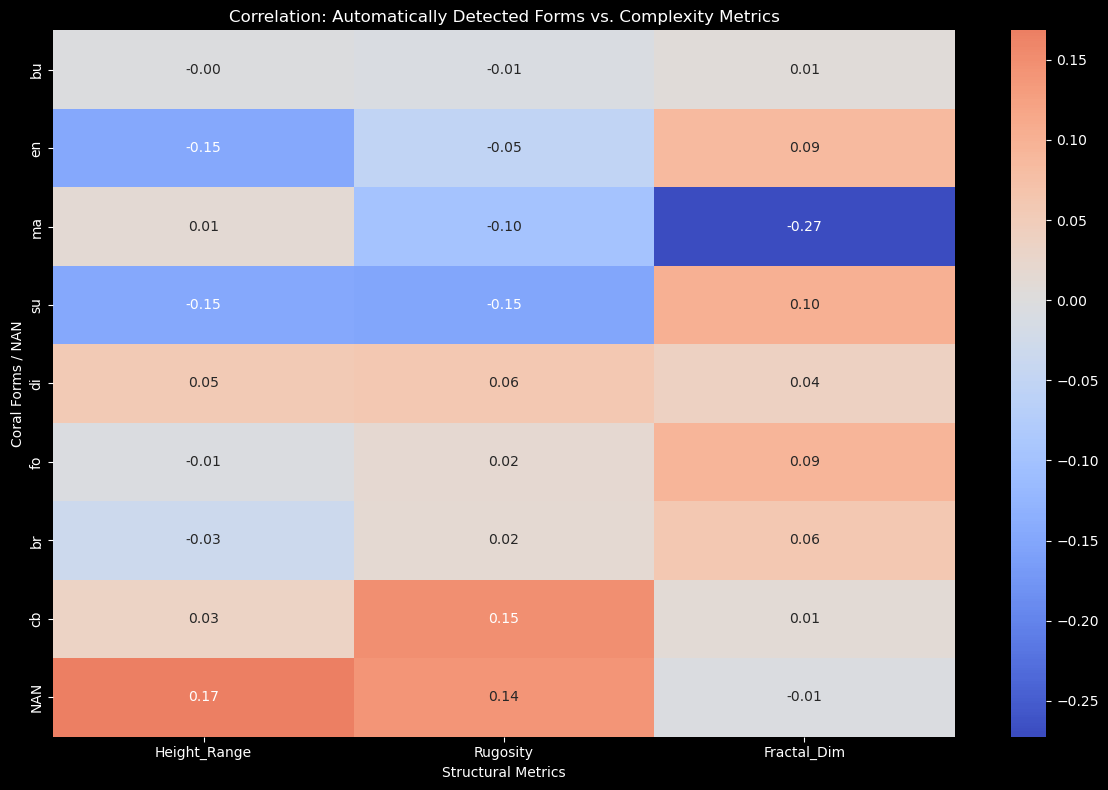

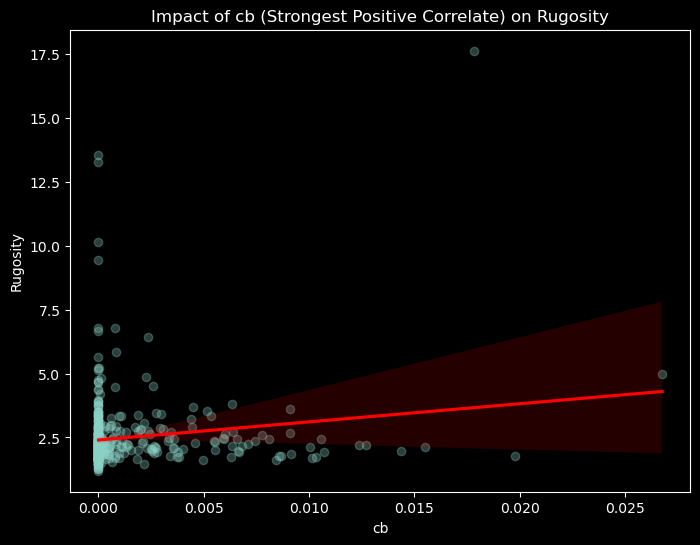

In [10]:
import arcpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 環境與參數設定
input_layer = "DEM_Grid_512"
metrics = ['Height_Range', 'Rugosity', 'Fractal_Dim']

# 2. 自動偵測 Form 欄位 (規則：長度為 2 的純英文字母，或名稱為 NAN)
all_fields = arcpy.ListFields(input_layer)
form_cols = []

for f in all_fields:
    name = f.name
    # 檢查是否為兩個字母 (如 bu, en) 或者剛好是 NAN
    if (len(name) == 2 and name.isalpha()) or name.upper() == "NAN":
        form_cols.append(name)

print(f"自動偵測到的 Form 欄位: {form_cols}")

# 3. 讀取資料
# 確保我們只讀取存在的指標欄位
existing_metrics = [m for m in metrics if m in [f.name for f in all_fields]]
load_fields = form_cols + existing_metrics

arr = arcpy.da.FeatureClassToNumPyArray(input_layer, load_fields)
df = pd.DataFrame(arr)

# 4. 統計分析：相關性矩陣
# 計算所有 Form 與指標之間的關係
corr_matrix = df.corr().loc[form_cols, existing_metrics]

# 5. 視覺化 - 熱圖 (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation: Automatically Detected Forms vs. Complexity Metrics")
plt.ylabel("Coral Forms / NAN")
plt.xlabel("Structural Metrics")
plt.tight_layout()
plt.show()

# 6. 自動化回歸分析：找出對 Rugosity 影響最大的 Form 並繪圖
if 'Rugosity' in existing_metrics:
    # 找出與 Rugosity 相關性絕對值最高的 Form (排除 NAN 自己，通常 NAN 是負相關)
    forms_only = [f for f in form_cols if f.upper() != "NAN"]
    if forms_only:
        best_form = corr_matrix['Rugosity'].loc[forms_only].idxmax()
        
        plt.figure(figsize=(8, 6))
        sns.regplot(data=df, x=best_form, y='Rugosity', 
                    scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
        plt.title(f"Impact of {best_form} (Strongest Positive Correlate) on Rugosity")
        plt.show()

In [13]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 基本設定與路徑 (請修改這裡)
input_layer = "DEM_Grid_512"
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output"  # 指定存檔資料夾

# 如果資料夾不存在，自動建立
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"已建立資料夾: {output_folder}")

# 2. 讀取資料與欄位辨識
all_fields = [f.name for f in arcpy.ListFields(input_layer)]
forms = [f for f in all_fields if len(f) == 2 and f.isalpha()]
metrics = ['Height_Range', 'Rugosity', 'Fractal_Dim']
existing_metrics = [m for m in metrics if m in all_fields]

arr = arcpy.da.FeatureClassToNumPyArray(input_layer, forms + existing_metrics + ["Shape_Area"])
df = pd.DataFrame(arr)

# 3. 數據預處理
df['Total_Coral_Area'] = df[forms].sum(axis=1)
df['Coverage_Pct'] = (df['Total_Coral_Area'] / df['Shape_Area']) * 100
df_comp = df[forms].div(df['Total_Coral_Area'].replace(0, np.nan), axis=0).fillna(0)
ratio_cols = [f + '_ratio' for f in forms]
df_comp.columns = ratio_cols
df = pd.concat([df, df_comp], axis=1)

# 分層設定
bins = [0, 25, 50, 75, 100]
labels = ['Low (0-25%)', 'Mid-Low (25-50%)', 'Mid-High (50-75%)', 'High (75-100%)']
df['Coverage_Bin'] = pd.cut(df['Coverage_Pct'], bins=bins, labels=labels, include_lowest=True)

# 4. 執行分析並儲存圖表
for metric in existing_metrics:
    bin_results = []
    for bin_name, group in df.groupby('Coverage_Bin'):
        if len(group) > 3:
            correlations = group[ratio_cols].corrwith(group[metric])
            correlations.name = bin_name
            bin_results.append(correlations)
    
    if bin_results:
        comparison_df = pd.concat(bin_results, axis=1)
        comparison_df.index = [i.replace('_ratio', '') for i in comparison_df.index]
        
        # 繪圖
        plt.figure(figsize=(10, 7))
        sns.heatmap(comparison_df, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
        plt.title(f"Impact of Form Composition on [{metric}]\n(Segmented by Total Coverage)")
        plt.ylabel("Coral Form Percentage")
        plt.xlabel("Total Grid Coverage Bin")
        plt.tight_layout()
        
        # --- 儲存熱圖 ---
        save_path = os.path.join(output_folder, f"Heatmap_{metric}.png")
        plt.savefig(save_path, dpi=300) # 設定 300 DPI 高畫質
        print(f"已儲存: {save_path}")
        plt.close() # 關閉畫布以節省記憶體

# 5. 儲存總體趨勢圖
plt.figure(figsize=(18, 5))
for i, metric in enumerate(existing_metrics):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(data=df, x='Coverage_Pct', y=metric, alpha=0.4, edgecolor=None)
    sns.regplot(data=df, x='Coverage_Pct', y=metric, scatter=False, color='red')
    plt.title(f'Overall Trend: {metric}')

save_path_trend = os.path.join(output_folder, "Overall_Trends.png")
plt.savefig(save_path_trend, dpi=300)
print(f"已儲存總趨勢圖: {save_path_trend}")
plt.close()

print("\n--- 所有分析圖表已成功輸出至指定資料夾 ---")

C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/668755963.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, group in df.groupby('Coverage_Bin'):
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3

已儲存: D:\ArcGIS\Morpho_Spatial_Demography\output\Heatmap_Height_Range.png


C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/668755963.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, group in df.groupby('Coverage_Bin'):
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3

已儲存: D:\ArcGIS\Morpho_Spatial_Demography\output\Heatmap_Rugosity.png


C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/668755963.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, group in df.groupby('Coverage_Bin'):
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3

已儲存: D:\ArcGIS\Morpho_Spatial_Demography\output\Heatmap_Fractal_Dim.png
已儲存總趨勢圖: D:\ArcGIS\Morpho_Spatial_Demography\output\Overall_Trends.png

--- 所有分析圖表已成功輸出至指定資料夾 ---


In [16]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 忽略 Numpy 計算斜率時可能出現的除零警告
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ==========================================
# 1. 基本設定與資料準備
# ==========================================
input_layer = "DEM_Grid_512"
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output" # 修改輸出路徑以示區別

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"已建立輸出資料夾: {output_folder}")

# 讀取欄位與資料
all_fields = [f.name for f in arcpy.ListFields(input_layer)]
forms = [f for f in all_fields if len(f) == 2 and f.isalpha()]
metrics = ['Height_Range', 'Rugosity', 'Fractal_Dim']
existing_metrics = [m for m in metrics if m in all_fields]

# 轉為 DataFrame
arr = arcpy.da.FeatureClassToNumPyArray(input_layer, forms + existing_metrics + ["Shape_Area"])
df = pd.DataFrame(arr)

# 計算覆蓋率與組成比例
df['Total_Coral_Area'] = df[forms].sum(axis=1)
df['Coverage_Pct'] = (df['Total_Coral_Area'] / df['Shape_Area']) * 100
df_comp = df[forms].div(df['Total_Coral_Area'].replace(0, np.nan), axis=0).fillna(0)
ratio_cols = [f + '_ratio' for f in forms]
df_comp.columns = ratio_cols
df = pd.concat([df, df_comp], axis=1)

# 分層設定
bins = [0, 25, 50, 75, 100]
labels = ['Low (0-25%)', 'Mid-Low (25-50%)', 'Mid-High (50-75%)', 'High (75-100%)']
df['Coverage_Bin'] = pd.cut(df['Coverage_Pct'], bins=bins, labels=labels, include_lowest=True)

# ==========================================
# 2. 計算預期增益 (斜率計算)
# ==========================================
def get_slope(x, y):
    # 確保有足夠的變動性和樣本數進行回歸
    if len(x) < 5 or x.std() == 0 or y.std() == 0:
        return 0
    try:
        slope, intercept = np.polyfit(x, y, 1)
        return slope
    except:
        return 0

increase_unit = 0.10  # 設定增加 10%
prediction_results = []

print("開始計算各 Form 的預期增益斜率...")
for metric in existing_metrics:
    # 使用 observed=False 避免未來的 Pandas 警告
    for bin_name, group in df.groupby('Coverage_Bin', observed=False):
        for f in forms:
            f_ratio = f + '_ratio'
            # 計算斜率
            slope = get_slope(group[f_ratio], group[metric])
            # 計算增加 10% 的預期增益
            expected_gain = slope * increase_unit
            
            prediction_results.append({
                'Metric': metric,
                'Coverage': bin_name,
                'Form': f,
                'Gain_per_10pct': expected_gain
            })

predict_df = pd.DataFrame(prediction_results)

# ==========================================
# 3. 資料過濾與視覺化設定 (關鍵修改)
# ==========================================

# --- 關鍵修改 1：剔除指定的 Form (bu) ---
form_to_exclude = 'bu'
if form_to_exclude in predict_df['Form'].unique():
    predict_df_filtered = predict_df[predict_df['Form'] != form_to_exclude].copy()
    print(f"\n已在視覺化資料中剔除樣本較少的 Form: '{form_to_exclude}'")
else:
    predict_df_filtered = predict_df.copy()
    print(f"\n資料中未發現 '{form_to_exclude}'，無需剔除。")

# --- 關鍵修改 2：設定高對比色票 ---
# 使用 'tab10' (Tableau 10色) 或 'Set1' 來獲得最大區別度
high_contrast_palette = 'tab10' 
sns.set_theme(style="whitegrid") # 設定白色網格背景，讓數值更容易讀
sns.set_palette(high_contrast_palette) # 套用高對比色票

# ==========================================
# 4. 繪圖並輸出
# ==========================================
print(f"\n開始繪圖並輸出至 {output_folder}...")

for metric in existing_metrics:
    plt.figure(figsize=(12, 7)) # 稍微加大畫布
    
    # 取出該指標的資料子集
    subset_filtered = predict_df_filtered[predict_df_filtered['Metric'] == metric]
    
    # 繪製條形圖，指定 hue 為 Form，並使用設定好的高對比色票
    ax = sns.barplot(
        data=subset_filtered, 
        x='Coverage', 
        y='Gain_per_10pct', 
        hue='Form', 
        palette=high_contrast_palette,
        edgecolor="black", # 增加黑色邊框讓條形更清晰
        linewidth=0.8
    )
    
    # 添加一條 0 的基準線
    plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
    
    # 設定標題與標籤
    plt.title(f"Predicted Impact on [{metric}] if Form Proportion Increases by 10%\n(Excluding '{form_to_exclude}')", fontsize=14, fontweight='bold')
    plt.ylabel(f"Expected Gain in {metric} (Value)", fontsize=12)
    plt.xlabel("Total Coral Coverage Bin", fontsize=12)
    
    # 優化圖例位置
    plt.legend(title='Coral Form', title_fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    
    # 儲存高解析度圖片
    save_path = os.path.join(output_folder, f"Prediction_HighContrast_{metric}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # bbox_inches='tight' 確保圖例不會被裁切
    print(f"已儲存圖表: {save_path}")
    plt.close() # 關閉畫布

# 順便儲存過濾後的數據表
csv_path = os.path.join(output_folder, "Predicted_Gain_Filtered_Data.csv")
predict_df_filtered.to_csv(csv_path, index=False)
print(f"\n已儲存過濾後的數據表: {csv_path}")
print("所有作業完成。")

開始計算各 Form 的預期增益斜率...

已在視覺化資料中剔除樣本較少的 Form: 'bu'

開始繪圖並輸出至 D:\ArcGIS\Morpho_Spatial_Demography\output...
已儲存圖表: D:\ArcGIS\Morpho_Spatial_Demography\output\Prediction_HighContrast_Height_Range.png
已儲存圖表: D:\ArcGIS\Morpho_Spatial_Demography\output\Prediction_HighContrast_Rugosity.png
已儲存圖表: D:\ArcGIS\Morpho_Spatial_Demography\output\Prediction_HighContrast_Fractal_Dim.png

已儲存過濾後的數據表: D:\ArcGIS\Morpho_Spatial_Demography\output\Predicted_Gain_Filtered_Data.csv
所有作業完成。


C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/381366820.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Estimate', y='Term', palette=colors, edgecolor='black')
C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/381366820.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Estimate', y='Term', palette=colors, edgecolor='black')


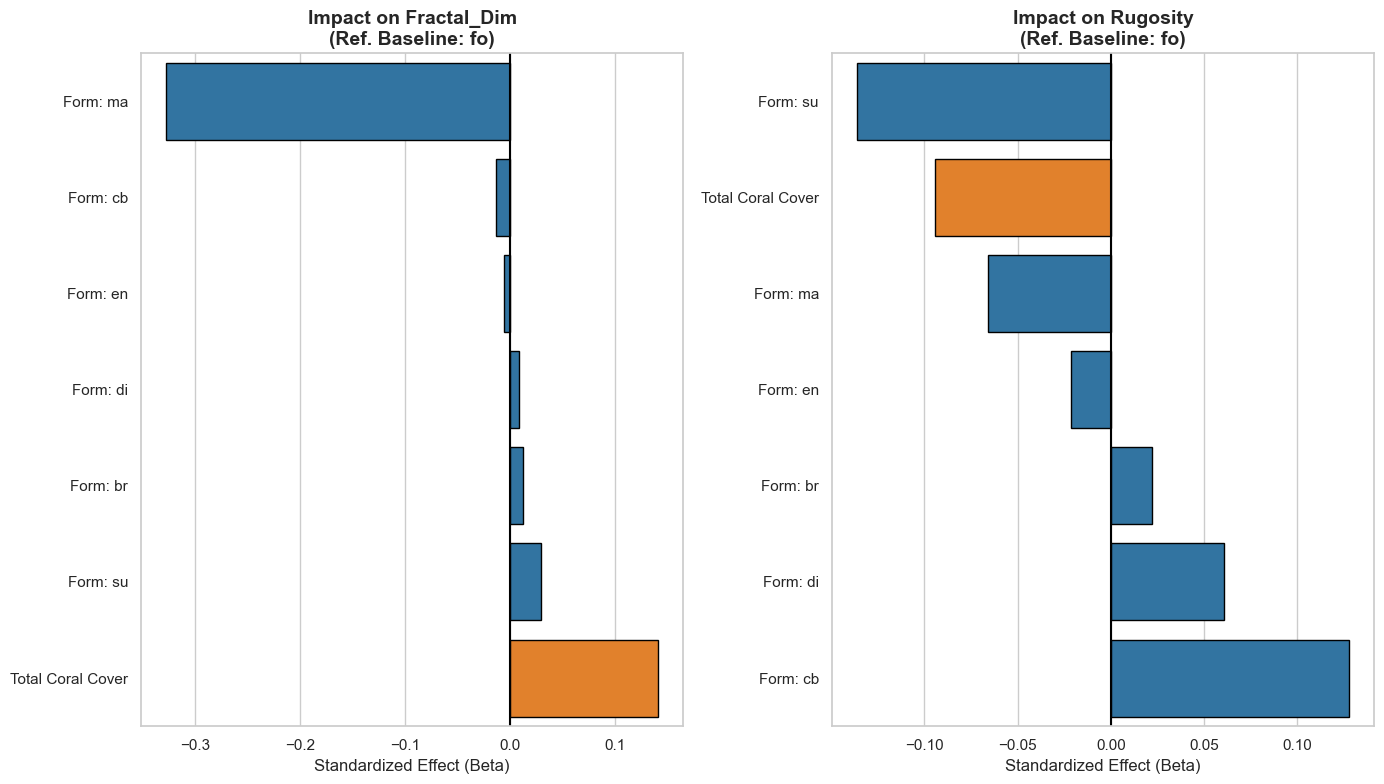

分析完成！圖片與 CSV 已儲存至 D:\ArcGIS\Morpho_Spatial_Demography\output


In [18]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 參數設定
input_fc = "DEM_Grid_512"  
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output"
if not os.path.exists(output_folder): os.makedirs(output_folder)

# 定義變數 (移除 source_field)
predictors = ["br", "cb", "di", "ma", "en", "fo", "su", "NAN"]
responses = ["Fractal_Dim", "Rugosity"] 

# 2. 讀取資料
fields = predictors + responses
arr = arcpy.da.FeatureClassToNumPyArray(input_fc, fields)
df = pd.DataFrame(arr)

# 3. 特徵工程 (Feature Engineering)
# 計算總珊瑚覆蓋度 (Quantity)
df['Coral_Cover'] = 1.0 - df['NAN']

# 計算「相對」生長型比例 (Composition)
rel_predictors = []
for p in [f for f in predictors if f != "NAN"]:
    rel_name = f"Rel_{p}"
    # 僅在有珊瑚的網格計算比例，否則設為 0
    df[rel_name] = np.where(df['Coral_Cover'] > 0, df[p] / df['Coral_Cover'], 0)
    rel_predictors.append(rel_name)

# 4. 統計分析函數 (單一母體版)
def analyze_relative_impact(data, target_y, rel_preds):
    # 過濾掉完全沒有珊瑚的網格 (因為比例無意義)
    sub_data = data[data['Coral_Cover'] > 0].copy()
    
    # 選擇需要的欄位並去除空值
    analysis_cols = [target_y, "Coral_Cover"] + rel_preds
    final_data = sub_data[analysis_cols].dropna()
    
    # 過濾變異數為 0 的欄位 (例如某型態在全區都沒出現)
    valid_rel_preds = [p for p in rel_preds if final_data[p].std() > 0]
    
    if len(final_data) < 10: return None
        
    # 自動選擇基準 (Baseline)：平均佔比最大的型態
    avg_props = final_data[valid_rel_preds].mean()
    baseline_var = avg_props.idxmax()
    
    # 預測變數 = 總量 + (組成比例 - 基準)
    model_preds = ["Coral_Cover"] + [p for p in valid_rel_preds if p != baseline_var]
    
    # 標準化數據 (Z-score)
    subset = final_data[[target_y] + model_preds]
    scaled_data = (subset - subset.mean()) / subset.std()
    
    # 執行回歸 (OLS)
    y = scaled_data[target_y].values
    X = scaled_data[model_preds].values
    X = np.hstack([np.ones((X.shape[0], 1)), X]) # 加入截距項
    
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    
    # 整理結果
    results = []
    for i, name in enumerate(["Intercept"] + model_preds):
        if name == "Intercept": continue
        
        # 標記變數類型
        term_type = "Total Quantity" if name == "Coral_Cover" else "Morpho Composition"
        term_label = "Total Coral Cover" if name == "Coral_Cover" else f"Form: {name.replace('Rel_', '')}"
        
        results.append({
            'Term': term_label,
            'Type': term_type,
            'Estimate': beta[i],
            'Response': target_y,
            'Baseline': baseline_var.replace("Rel_", "")
        })
    return results

# 5. 執行分析
all_results = []
for resp in responses:
    res = analyze_relative_impact(df, resp, rel_predictors)
    if res:
        all_results.extend(res)

results_df = pd.DataFrame(all_results)

# 6. 繪圖 (Forest Plot 形式的條形圖)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

for i, resp in enumerate(responses):
    plt.subplot(1, 2, i+1)
    plot_data = results_df[results_df['Response'] == resp].sort_values('Estimate', ascending=True)
    
    # 使用明顯的顏色區分「總量」與「組成」
    colors = ["#ff7f0e" if t == "Total Quantity" else "#1f77b4" for t in plot_data['Type']]
    
    sns.barplot(data=plot_data, x='Estimate', y='Term', palette=colors, edgecolor='black')
    
    # 標註基準 (Baseline)
    baseline = plot_data['Baseline'].iloc[0]
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.title(f"Impact on {resp}\n(Ref. Baseline: {baseline})", fontsize=14, fontweight='bold')
    plt.xlabel("Standardized Effect (Beta)")
    plt.ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Global_Coral_Impact_Analysis.png"), dpi=300)
plt.show()

# 儲存係數表供查閱
results_df.to_csv(os.path.join(output_folder, "Beta_Coefficients.csv"), index=False)
print(f"分析完成！圖片與 CSV 已儲存至 {output_folder}")

In [19]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestRegressor

# 1. 參數與資料讀取
input_fc = "DEM_Grid_512"
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output"
if not os.path.exists(output_folder): os.makedirs(output_folder)

# 定義 Form 和 指標
predictors = ["br", "cb", "di", "ma", "en", "fo", "su", "NAN"]
responses = ["Fractal_Dim", "Rugosity"]

# 轉為 DataFrame
fields = predictors + responses + ["Shape_Area"]
arr = arcpy.da.FeatureClassToNumPyArray(input_fc, fields)
df = pd.DataFrame(arr)

# 2. 資料前處理：計算各 Form 的絕對面積或覆蓋率
# 這裡建議使用 "覆蓋率 (Proportion)" 因為這已經正規化了網格大小
df['Total_Area'] = df["Shape_Area"] # 假設網格大小一致，若不一致請用 Shape_Area
for p in predictors:
    # 這裡直接用原始面積值做分析 (RF 對數值尺度不敏感，面積或比例皆可)
    # 若你的 Form 欄位已經是面積，則直接使用
    pass 

# 3. 定義計算百分比貢獻的函數
def calculate_importance(data, target_y, predictors):
    # 建立 X (特徵) 和 y (目標)
    X = data[predictors].fillna(0)
    y = data[target_y]
    
    # 初始化隨機森林模型
    # n_estimators=100: 建立 100 棵決策樹
    # random_state=42: 確保每次跑結果一致
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # 取得特徵重要性 (Feature Importances)
    # 這是基於 "Mean Decrease in Impurity" (MDI)
    # 數值總和會自動為 1.0
    importances = rf.feature_importances_
    
    # 整理結果
    result_df = pd.DataFrame({
        'Form': predictors,
        'Importance': importances,
        'Percentage': importances * 100,
        'Target': target_y
    })
    
    # 排序
    return result_df.sort_values(by='Importance', ascending=False)

# 4. 執行分析
final_results = []

for resp in responses:
    print(f"正在計算 {resp} 的貢獻百分比...")
    imp_df = calculate_importance(df, resp, predictors)
    final_results.append(imp_df)

all_importance = pd.concat(final_results)

# 5. 視覺化：百分比貢獻圖 (Donut Chart 或 Bar Chart)
# 為了清楚展示，我們用兩張圖分別畫 Fractal_Dim 和 Rugosity

for resp in responses:
    subset = all_importance[all_importance['Target'] == resp]
    
    # 設定圖表
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # 繪製條形圖
    # 使用 Spectral 配色讓不同 Form 容易區分
    ax = sns.barplot(data=subset, x='Percentage', y='Form', palette='Spectral')
    
    # 在條形上標註具體數值
    for i, p in enumerate(ax.patches):
        percentage = p.get_width()
        if percentage > 1: # 只標註大於 1% 的
            ax.annotate(f"{percentage:.1f}%", 
                        (p.get_x() + p.get_width() + 0.5, p.get_y() + p.get_height()/2),
                        va='center', fontsize=10, fontweight='bold')
    
    plt.title(f"Percentage Contribution of Forms to [{resp}]\n(Based on Random Forest Feature Importance)", fontsize=14)
    plt.xlabel("Contribution (%)")
    plt.ylabel("Growth Form")
    plt.xlim(0, max(subset['Percentage']) * 1.15) # 留點空間給標籤
    
    plt.tight_layout()
    save_path = os.path.join(output_folder, f"Percentage_Contribution_{resp}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

# 輸出表格
csv_path = os.path.join(output_folder, "Form_Percentage_Contribution.csv")
all_importance.to_csv(csv_path, index=False)
print(f"計算完成！結果已儲存至: {csv_path}")

# 顯示簡單摘要
print("\n--- 摘要：各指標的最大貢獻者 ---")
for resp in responses:
    top_form = all_importance[all_importance['Target'] == resp].iloc[0]
    print(f"[{resp}] 主要由 {top_form['Form']} 貢獻 ({top_form['Percentage']:.1f}%)")

<class 'ModuleNotFoundError'>: No module named 'sklearn'

正在計算 Fractal_Dim 的貢獻百分比...
正在計算 Rugosity 的貢獻百分比...


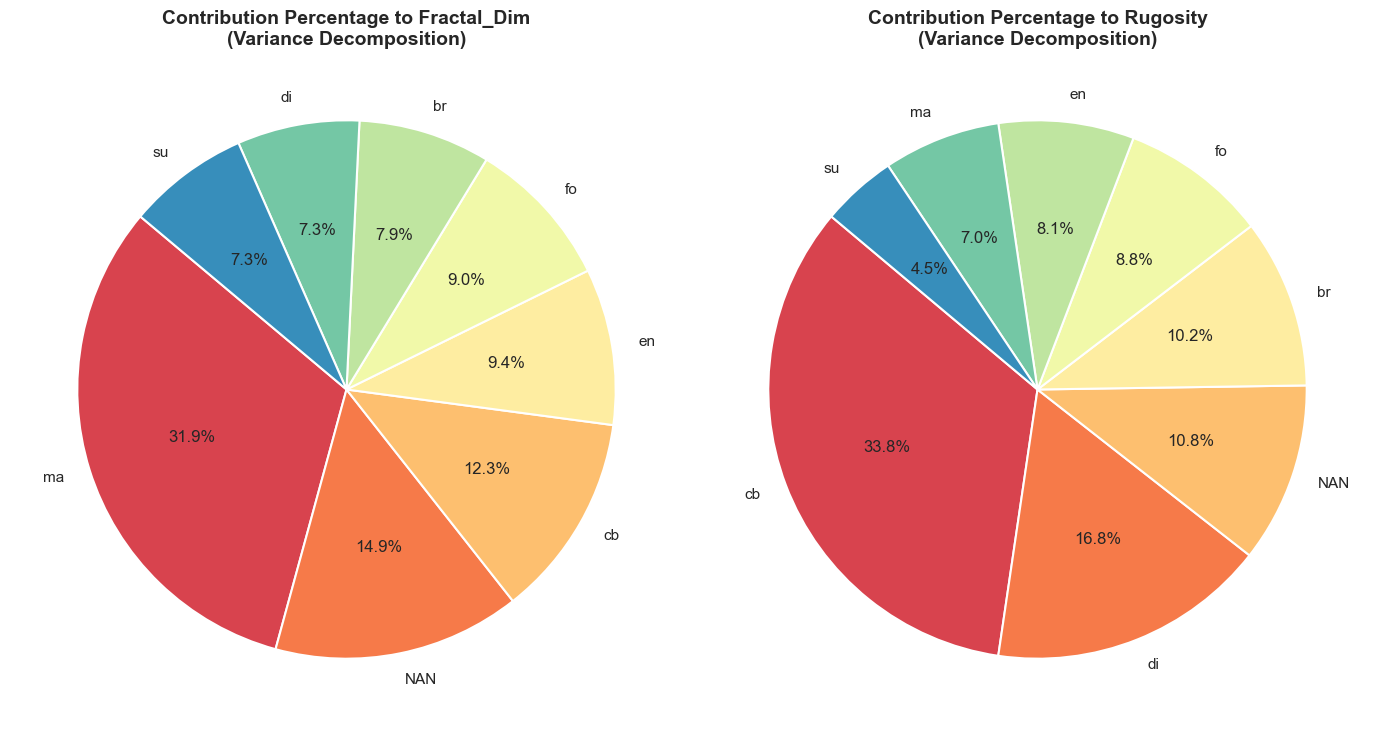

分析完成，圓餅圖與表格已輸出。


In [20]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 參數設定
input_fc = "DEM_Grid_512"
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output"
if not os.path.exists(output_folder): os.makedirs(output_folder)

# 定義變數
predictors = ["br", "cb", "di", "ma", "en", "fo", "su", "NAN"]
responses = ["Fractal_Dim", "Rugosity"]

# 2. 讀取與清理資料
fields = predictors + responses
arr = arcpy.da.FeatureClassToNumPyArray(input_fc, fields)
df = pd.DataFrame(arr).dropna()

# 3. 變異數分解函數 (使用最小平方法)
def calculate_variance_contribution(data, target_y, predictors):
    # 準備數據
    y = data[target_y].values
    X_all = data[predictors].values
    X_all = np.hstack([np.ones((X_all.shape[0], 1)), X_all]) # 加入截距項
    
    # 定義計算 R-squared 的閉式解
    def get_r2(X, y):
        try:
            beta, res, _, _ = np.linalg.lstsq(X, y, rcond=None)
            sse = res[0] if len(res) > 0 else np.sum((y - X @ beta)**2)
            sst = np.sum((y - np.mean(y))**2)
            return 1 - (sse / sst)
        except:
            return 0

    # 全模型的 R2
    full_r2 = get_r2(X_all, y)
    
    contributions = []
    for p in predictors:
        # 移除該變數後的 X
        other_preds = [item for item in predictors if item != p]
        X_sub = data[other_preds].values
        X_sub = np.hstack([np.ones((X_sub.shape[0], 1)), X_sub])
        
        # 解釋力下降量 (Marginal Contribution)
        drop_r2 = full_r2 - get_r2(X_sub, y)
        contributions.append(max(0, drop_r2)) # 確保不為負數

    # 歸一化為百分比
    total_drop = sum(contributions)
    if total_drop == 0: return pd.DataFrame()
    
    percentages = [(c / total_drop) * 100 for c in contributions]
    
    return pd.DataFrame({
        'Form': predictors,
        'Contribution_Pct': percentages,
        'Target': target_y
    })

# 4. 執行計算並繪圖
all_results = []
for resp in responses:
    print(f"正在計算 {resp} 的貢獻百分比...")
    res_df = calculate_variance_contribution(df, resp, predictors)
    all_results.append(res_df)

final_df = pd.concat(all_results)

# 5. 視覺化：百分比貢獻圖
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

for i, resp in enumerate(responses):
    plt.subplot(1, 2, i+1)
    plot_data = final_df[final_df['Target'] == resp].sort_values('Contribution_Pct', ascending=False)
    
    # 繪製圓餅圖 (Pie Chart) 最能體現「百分比」的概念
    colors = sns.color_palette("Spectral", len(plot_data))
    plt.pie(plot_data['Contribution_Pct'], labels=plot_data['Form'], 
            autopct='%1.1f%%', startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    
    plt.title(f"Contribution Percentage to {resp}\n(Variance Decomposition)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "Variance_Contribution_Pie.png"), dpi=300)
plt.show()

# 6. 輸出表格
final_df.to_csv(os.path.join(output_folder, "Contribution_Percentage_Table.csv"), index=False)
print("分析完成，圓餅圖與表格已輸出。")

處理指標: Fractal_Dim...
處理指標: Rugosity...


C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/522699352.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='Signed_Pct', y='Form', palette=colors, edgecolor='black', linewidth=1)
C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp22816/xpython_22816/522699352.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='Signed_Pct', y='Form', palette=colors, edgecolor='black', linewidth=1)


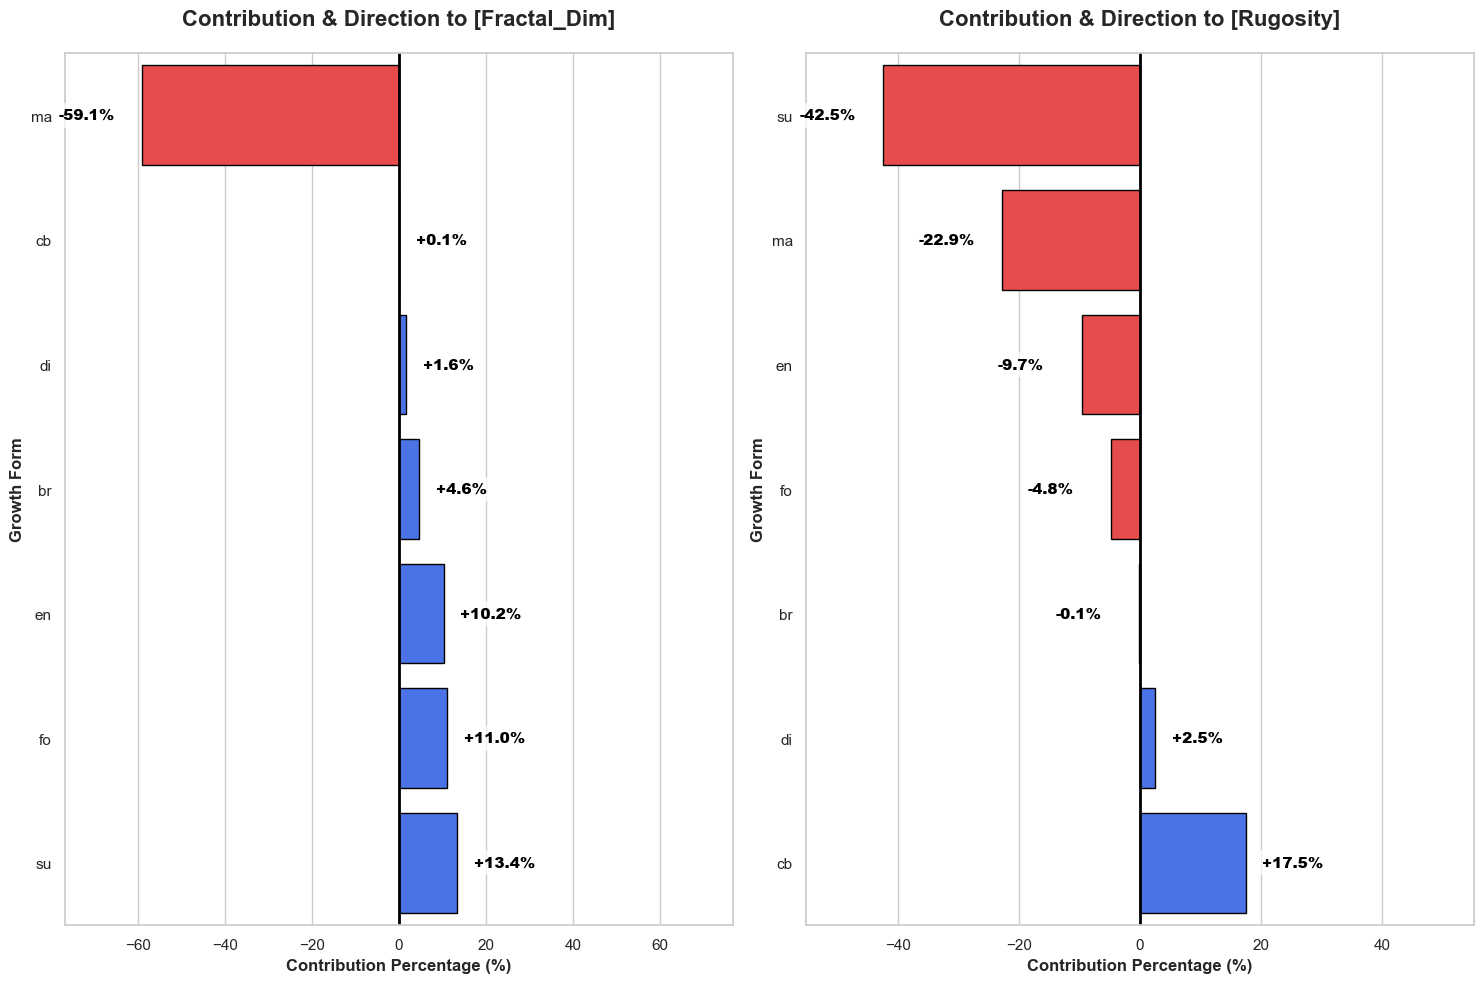

分析完成！圖片與 CSV 資料已儲存至: D:\ArcGIS\Morpho_Spatial_Demography\output


In [23]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 參數設定
input_fc = "DEM_Grid_512" 
output_folder = r"D:\ArcGIS\Morpho_Spatial_Demography\output"
if not os.path.exists(output_folder): os.makedirs(output_folder)

# ⚠️ 關鍵修正：將 NAN 從預測變數中移出，作為「基準基準線」
# 這樣剩下的 br, cb... 係數才代表「相對於非珊瑚區域」的貢獻
all_categories = ["br", "cb", "di", "ma", "en", "fo", "su", "NAN"]
predictors = [p for p in all_categories if p != "NAN"] # 移除 NAN
responses = ["Fractal_Dim", "Rugosity"]

# 2. 讀取資料
fields = all_categories + responses
arr = arcpy.da.FeatureClassToNumPyArray(input_fc, fields)
df = pd.DataFrame(arr).dropna()

# 3. 修正後的計算函數
def calculate_contribution_with_direction(data, target_y, predictors):
    y = data[target_y].values
    X_all = data[predictors].values
    X_all_const = np.hstack([np.ones((X_all.shape[0], 1)), X_all])
    
    # 計算回歸方向 (此時已排除 NAN，方向具備生態意義)
    beta_full, res, _, _ = np.linalg.lstsq(X_all_const, y, rcond=None)
    directions = np.sign(beta_full[1:]) 

    def get_sse(X, y):
        b, r, _, _ = np.linalg.lstsq(X, y, rcond=None)
        return r[0] if len(r) > 0 else np.sum((y - X @ b)**2)

    sst = np.sum((y - np.mean(y))**2)
    full_r2 = 1 - (get_sse(X_all_const, y) / sst)
    
    contributions = []
    for p in predictors:
        other_preds = [item for item in predictors if item != p]
        X_sub = data[other_preds].values
        X_sub_const = np.hstack([np.ones((X_sub.shape[0], 1)), X_sub])
        drop_r2 = full_r2 - (1 - (get_sse(X_sub_const, y) / sst))
        contributions.append(max(0, drop_r2))

    total_drop = sum(contributions)
    if total_drop == 0: return pd.DataFrame()
    
    signed_pcts = [(c / total_drop) * 100 * d for c, d in zip(contributions, directions)]
    
    return pd.DataFrame({
        'Form': predictors,
        'Signed_Pct': signed_pcts,
        'Abs_Pct': np.abs(signed_pcts),
        'Target': target_y
    })

# 4. 執行統計分析
all_results = []
for resp in responses:
    print(f"處理指標: {resp}...")
    res_df = calculate_contribution_with_direction(df, resp, predictors)
    all_results.append(res_df)

final_df = pd.concat(all_results)

# 5. 視覺化繪圖 (高對比色與符號標註)
plt.figure(figsize=(15, 10))
sns.set_theme(style="whitegrid") # 使用清晰的網格背景

for i, resp in enumerate(responses):
    plt.subplot(1, 2, i+1)
    # 按數值排序，讓圖表更美觀
    plot_data = final_df[final_df['Target'] == resp].sort_values('Signed_Pct')
    
    # 選用高對比色：正向鮮藍色，負向鮮紅色
    colors = ['#FF3333' if x < 0 else '#3366FF' for x in plot_data['Signed_Pct']]
    
    ax = sns.barplot(data=plot_data, x='Signed_Pct', y='Form', palette=colors, edgecolor='black', linewidth=1)
    
    # 繪製中央基準線
    plt.axvline(0, color='black', linewidth=2)
    
    # 標註標題與標籤
    plt.title(f"Contribution & Direction to [{resp}]", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Contribution Percentage (%)", fontsize=12, fontweight='bold')
    plt.ylabel("Growth Form", fontsize=12, fontweight='bold')

    # 設定 X 軸範圍，預留空間給文字標籤
    limit = max(plot_data['Abs_Pct'].max() * 1.3, 15)
    plt.xlim(-limit, limit)

    # --- 關鍵修改：在圖上顯示帶符號的百分比文字 ---
    for p in ax.patches:
        width = p.get_width()
        # 決定正負號文字
        sign_str = "+" if width > 0 else "-"
        label_text = f"{sign_str}{abs(width):.1f}%"
        
        # 調整文字位置 (正值往右放，負值往左放)
        x_pos = width + (limit * 0.05 if width > 0 else -limit * 0.25)
        
        ax.text(x_pos, p.get_y() + p.get_height()/2, label_text, 
                va='center', fontsize=11, fontweight='extra bold', 
                color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()

# 6. 輸出成果
save_path = os.path.join(output_folder, "Final_Directional_Contribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
final_df.to_csv(os.path.join(output_folder, "Contribution_Results_Table.csv"), index=False)

plt.show()
print(f"分析完成！圖片與 CSV 資料已儲存至: {output_folder}")